**Prática de Suavização de Imagens**

(filtro passa baixa)

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/mean.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/gsmooth.htm

http://homepages.inf.ed.ac.uk/rbf/HIPR2/median.htm

1)	Aplique o filtro de Média na imagem abaixo para diferentes tamanhos de máscaras.
- 3x3; 7x7; 3x3 aplicado três vezes sequenciais.

In [31]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

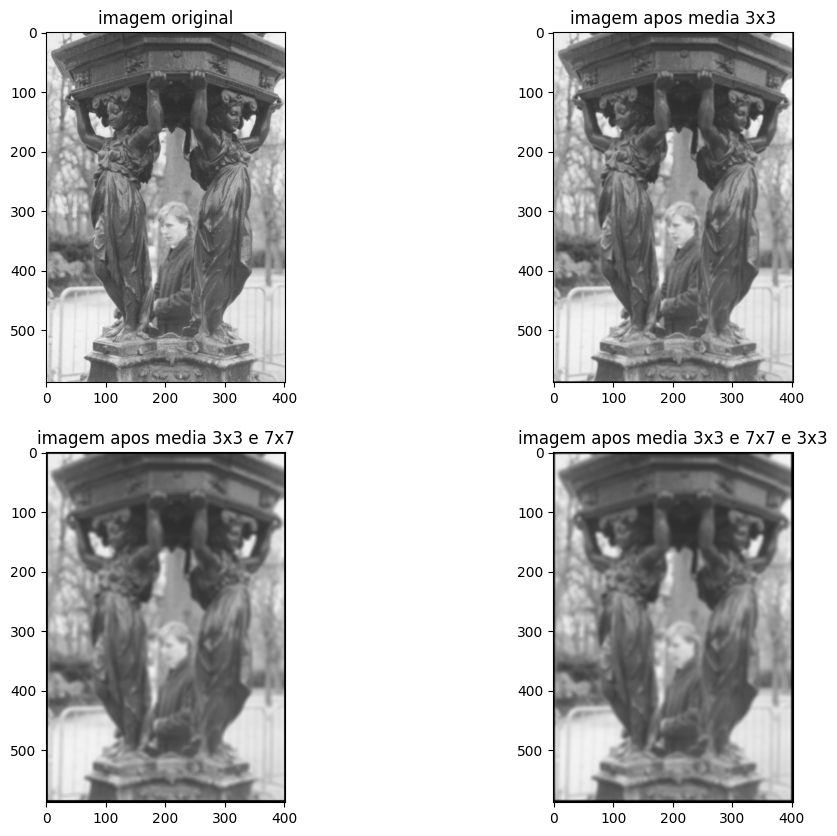

In [32]:

#Leonardo Oliveira de Jesus 12111EBI033
import cv2
import matplotlib.pyplot as plt
import numpy as np


def criar_mascara (tamanho):
    #matriz sempre quadrada
    matriz = (np.ones((tamanho,tamanho))) / (tamanho**2)
    return matriz


def filtro_media (img, tamanho_mascara):
    
    #Assim da para receber tanto o caminho quanto a nova matriz retornada
    if isinstance(img, str):
        imagem = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
    else:
        imagem = img.copy()
        
    linhas,colunas = imagem.shape
    
    #ignorar as bordas
    offset = tamanho_mascara//2
    
    #criar a mascara
    mascara = criar_mascara(tamanho_mascara)

    matriz_resultado = np.zeros(imagem.shape, dtype="float")
    
    for i in range (offset, linhas - offset):
        for j in range (offset, colunas - offset):
            
            regiao = imagem[i - offset : i + offset + 1,
                            j - offset : j + offset + 1]
            
            media = np.sum(regiao*mascara)
            
            matriz_resultado[i,j] = media
    return(matriz_resultado)
    


mascara_3x3         = filtro_media("sta2.png",3)
mascara_3x3_7x7     = filtro_media(mascara_3x3,7)
mascara_3x3_7x7_3x3 = filtro_media(mascara_3x3_7x7,3)

plt.figure(figsize=(12,10))
    
plt.subplot(2,2,2)
plt.imshow(mascara_3x3, cmap='gray', vmin=0, vmax=255)
plt.title("imagem apos media 3x3")

plt.subplot(2,2,3)
plt.imshow(mascara_3x3_7x7, cmap='gray', vmin=0, vmax=255)
plt.title("imagem apos media 3x3 e 7x7")

plt.subplot(2,2,4)
plt.imshow(mascara_3x3_7x7_3x3, cmap='gray', vmin=0, vmax=255)
plt.title("imagem apos media 3x3 e 7x7 e 3x3")
    
plt.subplot(2,2,1)
imagem_original = cv2.imread("sta2.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(imagem_original, cmap='gray', vmin=0, vmax=255)
plt.title("imagem original")
    
plt.show()

#E possivel ver um certo "blur" no resultado apos a aplicacao da media. Isso indica que funcionou o codigo, ocorrendo
# algo como se fosseum filtro apssa baixa




2)	Aplique o filtro Gaussiano à imagem abaixo para diferentes valores de desvio padrão (σ) e tamanho de máscara.
- σ = 1.0 (kernel size 5×5).	σ = 2.0 (kernel size 9×9).	σ =  4.0 (kernel size 15×15).

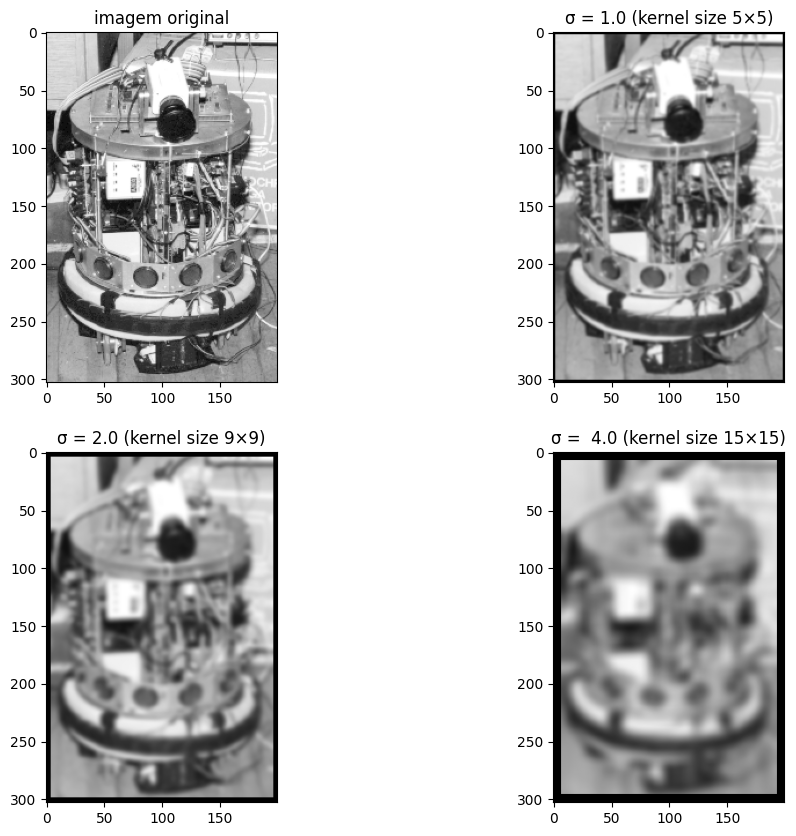

In [33]:
#Leonardo Oliveira de Jesus 12111EBI033

def criar_mascara_Gaussiana(tamanho,sigma):
    
    d = (tamanho // 2)
    eixo = np.arange(-d,d+1)
    
    x,y = np.meshgrid(eixo,eixo)
    
    #fórmula Gaussiana
    expoente = -(x**2 + y**2) / (2 * (sigma**2))
    mascara = np.exp(expoente)
    
    #soma da mascara sempre deve ser 1
    mascara = mascara / np.sum(mascara)
    
    return mascara

def filtro_gaussiana (img,tamanho_mascara,sigma):
    
    #Assim da para receber tanto o caminho quanto a nova matriz retornada
    if isinstance(img, str):
        imagem = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
    else:
        imagem = img.copy()
        
    linhas,colunas = imagem.shape
    
    #ignorar as bordas
    offset = tamanho_mascara//2
    
    #criar a mascara
    mascara = criar_mascara_Gaussiana(tamanho_mascara,sigma)

    matriz_resultado = np.zeros(imagem.shape, dtype="float")
    
    for i in range (offset, linhas - offset):
        for j in range (offset, colunas - offset):
            
            regiao = imagem[i - offset : i + offset + 1,
                            j - offset : j + offset + 1]
            
            media = np.sum(regiao*mascara)
            
            matriz_resultado[i,j] = media
    return(matriz_resultado)

#Imagem original
imagem_original_2 = cv2.imread("ben2.png", cv2.IMREAD_GRAYSCALE)

#aplicando os filros
gaus_sigma1_5   = filtro_gaussiana(imagem_original_2,5,1) # def filtro_gaussiana (imagem,tamanho,sigma)
gaus_sigma2_9   = filtro_gaussiana(imagem_original_2,9,2)
gaus_sigma4_15  = filtro_gaussiana(imagem_original_2,15,4)

plt.figure(figsize=(12,10))
    
plt.subplot(2,2,2)
plt.imshow(gaus_sigma1_5, cmap='gray', vmin=0, vmax=255)
plt.title("σ = 1.0 (kernel size 5×5)")

plt.subplot(2,2,3)
plt.imshow(gaus_sigma2_9, cmap='gray', vmin=0, vmax=255)
plt.title("σ = 2.0 (kernel size 9×9)")

plt.subplot(2,2,4)
plt.imshow(gaus_sigma4_15, cmap='gray', vmin=0, vmax=255)
plt.title("σ =  4.0 (kernel size 15×15)")
    
plt.subplot(2,2,1)
plt.imshow(imagem_original_2, cmap='gray', vmin=0, vmax=255)
plt.title("imagem original")
    
plt.show()


3)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído *salt and pepper*
-	3×3 filter;	7×7 filter

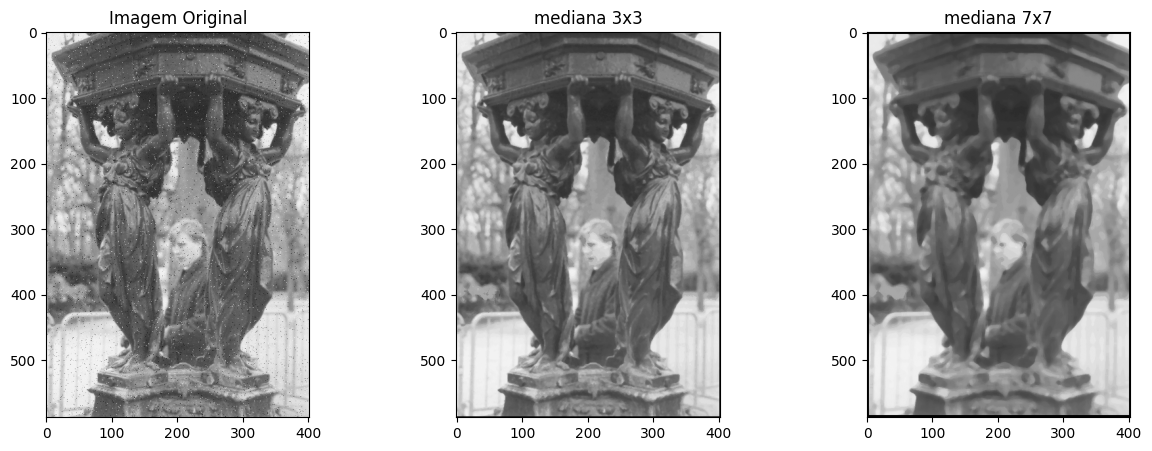

In [34]:
#Leonardo Oliveira de Jesus 12111EBI033
def filtro_mediana(img,tamanho):
    
    if isinstance (img, str):
        imagem = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    else:
        imagem = img.copy()
    
    linhas,colunas      = imagem.shape
    matriz_resultado    = np.zeros(imagem.shape, dtype="float")
    
    #offset para cortar as bordas
    offset = tamanho //2
    
    for i in range(offset, linhas-offset):
        for j in range(offset, colunas-offset):
            
            regiao = imagem[i - offset : i + offset + 1,
                            j - offset : j + offset + 1]
            
            lista = np.sort(regiao.flatten())
            tamanho_lista = len(lista)
            mediana = (tamanho_lista//2)
            valor_resultado = lista[mediana]
            
            matriz_resultado[i,j] = valor_resultado
    return(matriz_resultado)
            

img3 = cv2.imread("sta2noi2.png", cv2.IMREAD_GRAYSCALE)
Img3_filtrada_3x3 = filtro_mediana(img3,3)  
Img3_filtrada_7x7 = filtro_mediana(img3,7)  
    
plt.figure(figsize=(15,5)) 

plt.subplot(1,3,1)
plt.imshow(img3, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Original")

plt.subplot(1,3,2)
plt.imshow(Img3_filtrada_3x3, cmap='gray', vmin=0, vmax=255)
plt.title("mediana 3x3")

plt.subplot(1,3,3)
plt.imshow(Img3_filtrada_7x7, cmap='gray', vmin=0, vmax=255)
plt.title("mediana 7x7")

plt.show()

4)	Aplique o filtro de Mediana para a imagem abaixo, que apresenta um ruído salt and pepper. Não utilizar a função pronta do openvc, mas pode usar numpy.median()
- 3×3 filter;	7×7 filter

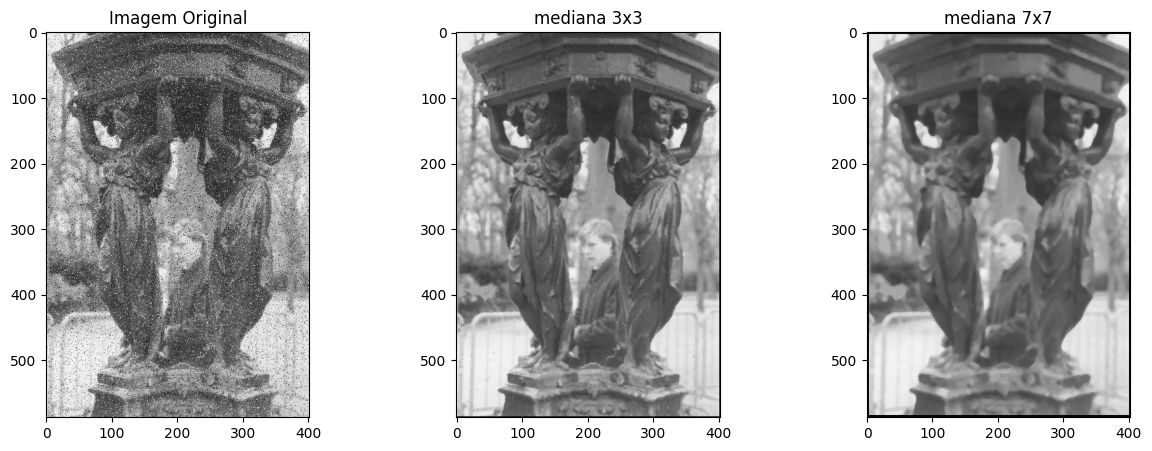

In [35]:
#Leonardo Oliveira de Jesus 12111EBI033

#Eu ja havia feito na questao 3 a funcao apra aplicar filtro de mediana seguindo a logica matematica desde o inicio
# (sem usar o median, trabalhando com lista)


img4 = cv2.imread("sta2noi1.png", cv2.IMREAD_GRAYSCALE)

Img4_filtrada_3x3 = filtro_mediana(img4,3)  
Img4_filtrada_7x7 = filtro_mediana(img4,7)  
    
plt.figure(figsize=(15,5)) 

plt.subplot(1,3,1)
plt.imshow(img4, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Original")

plt.subplot(1,3,2)
plt.imshow(Img4_filtrada_3x3, cmap='gray', vmin=0, vmax=255)
plt.title("mediana 3x3")

plt.subplot(1,3,3)
plt.imshow(Img4_filtrada_7x7, cmap='gray', vmin=0, vmax=255)
plt.title("mediana 7x7")

plt.show()